<a href="https://colab.research.google.com/github/cnsalsabila/myXLSentimentAnalysis/blob/main/Week%204/TF-IDF/TF-IDF_Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF : Danantara

## 1. Import Dependencies

In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.3 MB/s eta 0:00:00


In [2]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd
import math

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 2. Define Document

In [3]:
sentence = """
Danantara Siap Kawal Investasi USD4 Miliar Hasil Kerja Sama Indonesia-Qatar

Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.

Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola investasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia.
"""

print("Dokumen Berita:")
print(sentence[:300], "...")

Dokumen Berita:

Danantara Siap Kawal Investasi USD4 Miliar Hasil Kerja Sama Indonesia-Qatar

Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Pra ...


## 3. Text Preprocessing

In [4]:
# SENTENCE TOKENIZATION
sent_token = sent_tokenize(sentence)

print("Sentence Tokens:")
for i, s in enumerate(sent_token):
    print(f"{i+1}. {s}")
print(f"\nTotal kalimat: {len(sent_token)}")

Sentence Tokens:
1. 
Danantara Siap Kawal Investasi USD4 Miliar Hasil Kerja Sama Indonesia-Qatar

Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Da

In [5]:
# STOPWORD REMOVAL & CLEANING (menggunakan Sastrawi untuk Bahasa Indonesia)
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()
indonesian_stopwords = factory.get_stop_words()

cleaned_sentences = []

for sent in sent_token:
    # Hapus stopword bahasa Indonesia menggunakan Sastrawi
    removed = stopword_remover.remove(sent)
    # Tokenisasi kata, hanya ambil karakter alfabet
    words = word_tokenize(removed.lower())
    filtered_words = [w for w in words if w.isalpha()]
    cleaned_sentences.append(" ".join(filtered_words))

print("Cleaned Sentences (setelah stopword removal Bahasa Indonesia):")
for i, cs in enumerate(cleaned_sentences):
    print(f"{i+1}. {cs}")

Cleaned Sentences (setelah stopword removal Bahasa Indonesia):
1. danantara siap kawal investasi miliar hasil kerja sama badan pengelola investasi daya anagata nusantara bpi danantara siap mengawal realisasi investasi telah disepakati qatar
2. kesepakatan indonesia qatar merupakan buah kunjungan resmi presiden prabowo subianto doha
3. pemerintah republik indonesia pemerintah qatar menggelar diskusi menyepakati kemitraan strategis pengelolaan dana investasi indonesia akan berfokus berbagai sektor pembangunan
4. salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai miliar
5. dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri energi terbarukan fasilitas kesehatan indonesia
6. kami menyambut baik kepercayaan diberikan pemerintah qatar melalui pembentukan dana bersama ini kata ceo danantara indonesia rosan perkasa roeslani keterangan tertulis selasa april
7. presiden prabowo menyampaikan negara berkontri

## 4. TF-IDF Vectorization

In [6]:
# TRAINING TF-IDF VECTORIZER
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("TF-IDF Feature Matrix")
print(features)

print("\nShape (jumlah kalimat, jumlah kata unik):")
print(features.shape)

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 231 stored elements and shape (15, 155)>
  Coords	Values
  (0, 23)	0.3045551075681576
  (0, 136)	0.37647545269129673
  (0, 56)	0.21678092108159688
  (0, 50)	0.35757328109070613
  (0, 96)	0.1679860073892495
  (0, 42)	0.1679860073892495
  (0, 62)	0.18823772634564837
  (0, 129)	0.18823772634564837
  (0, 7)	0.21678092108159688
  (0, 107)	0.18823772634564837
  (0, 24)	0.21678092108159688
  (0, 3)	0.21678092108159688
  (0, 101)	0.21678092108159688
  (0, 17)	0.18823772634564837
  (0, 86)	0.21678092108159688
  (0, 122)	0.21678092108159688
  (0, 141)	0.21678092108159688
  (0, 32)	0.21678092108159688
  (0, 120)	0.12859119364835678
  (1, 120)	0.20192748514363137
  (1, 65)	0.34041231735378835
  (1, 45)	0.17414630282286622
  (1, 95)	0.29559077578884874
  (1, 18)	0.34041231735378835
  (1, 70)	0.29559077578884874
  :	:
  (13, 2)	0.2696904625735313
  (13, 151)	0.2696904625735313
  (14, 62)	0.1943911144408054
  (14, 129

In [7]:
# FEATURE NAMES (VOCABULARY)
feature_names = vectorizer.get_feature_names_out()

print("Vocabulary (Kata Unik Setelah Preprocessing)")
print(feature_names)
print(f"\nTotal kata dalam vocabulary: {len(feature_names)}")

Vocabulary (Kata Unik Setelah Preprocessing)
['adalah' 'akan' 'akuntabel' 'anagata' 'antaranya' 'april' 'authority'
 'badan' 'baik' 'berbagai' 'berfokus' 'berkelanjutan' 'berkontribusi'
 'berorientasi' 'bersama' 'berskala' 'besar' 'bpi' 'buah' 'bukti' 'ceo'
 'dampak' 'dana' 'danantara' 'daya' 'diberikan' 'didanai' 'difokuskan'
 'diharapkan' 'dikelola' 'dipandang' 'diplomatik' 'disepakati' 'diskusi'
 'doha' 'dunia' 'ekonomi' 'energi' 'fasilitas' 'fokus' 'global' 'hanya'
 'hasil' 'hilirisasi' 'hubungan' 'indonesia' 'industri' 'ini' 'inisiatif'
 'internasional' 'investasi' 'investment' 'juga' 'kami' 'kapasitas' 'kata'
 'kawal' 'kedua' 'kelembagaan' 'kelola' 'kemitraan' 'kepercayaan' 'kerja'
 'kesehatan' 'kesejahteraan' 'kesepakatan' 'keterangan' 'kolaborasi'
 'konkret' 'kontribusi' 'kunjungan' 'lain' 'langkah' 'lanjut' 'lebih'
 'mandat' 'masyarakat' 'melalui' 'memastikan' 'membangun' 'membentuk'
 'memberikan' 'memiliki' 'memperkuat' 'menegaskan' 'menerapkan' 'mengawal'
 'mengelola' 'mengg

In [8]:
# TF-IDF KALIMAT PERTAMA
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    """Mengembalikan DataFrame TF-IDF untuk kalimat tertentu."""
    tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': tfidf_values})
    df = df[df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return df

first_sentence_df = get_tfidf_for_sentence(features, 0, feature_names)

print("TF-IDF Kalimat Pertama (Sorted)")
print(first_sentence_df.to_string(index=False))

TF-IDF Kalimat Pertama (Sorted)
   Feature   TF-IDF
      siap 0.376475
 investasi 0.357573
 danantara 0.304555
 realisasi 0.216781
     badan 0.216781
   anagata 0.216781
disepakati 0.216781
  mengawal 0.216781
     kawal 0.216781
 nusantara 0.216781
      daya 0.216781
     telah 0.216781
       bpi 0.188238
 pengelola 0.188238
     kerja 0.188238
      sama 0.188238
     hasil 0.167986
    miliar 0.167986
     qatar 0.128591


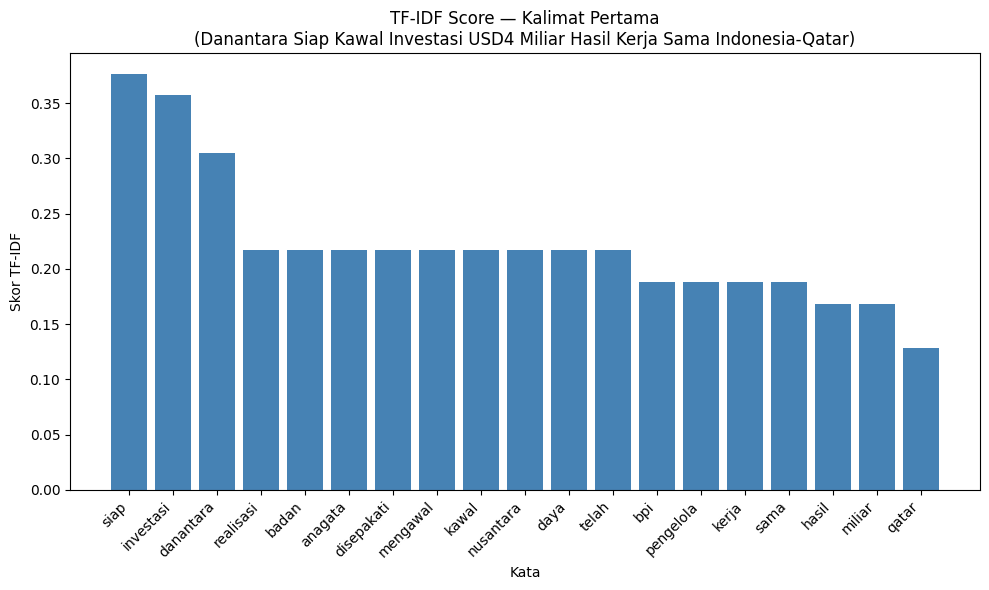

In [9]:
# VISUALISASI TF-IDF KALIMAT PERTAMA
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_df['Feature'], first_sentence_df['TF-IDF'], color='steelblue')
plt.xlabel("Kata")
plt.ylabel("Skor TF-IDF")
plt.title("TF-IDF Score — Kalimat Pertama\n(Danantara Siap Kawal Investasi USD4 Miliar Hasil Kerja Sama Indonesia-Qatar)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Hitung Sentence Score

In [10]:
# HITUNG RATA-RATA SKOR TF-IDF PER KALIMAT
sent_scores = []

print("Average TF-IDF Score per Kalimat")

for i in range(features.shape[0]):
    row = features[i]
    sum_score  = row.sum()
    word_count = len(row.data)
    avg_score  = sum_score / word_count if word_count > 0 else 0
    sent_scores.append(avg_score)

    print(f"Kalimat {i+1:2d} | Sum: {sum_score:.4f} | Words: {word_count:3d} | Avg: {avg_score:.4f}")

print("\nSemua Sentence Scores:")
print(sent_scores)

Average TF-IDF Score per Kalimat
Kalimat  1 | Sum: 4.2071 | Words:  19 | Avg: 0.2214
Kalimat  2 | Sum: 3.2605 | Words:  11 | Avg: 0.2964
Kalimat  3 | Sum: 3.9476 | Words:  17 | Avg: 0.2322
Kalimat  4 | Sum: 3.5388 | Words:  13 | Avg: 0.2722
Kalimat  5 | Sum: 4.0636 | Words:  17 | Avg: 0.2390
Kalimat  6 | Sum: 4.7194 | Words:  23 | Avg: 0.2052
Kalimat  7 | Sum: 2.9578 | Words:   9 | Avg: 0.3286
Kalimat  8 | Sum: 3.1007 | Words:  10 | Avg: 0.3101
Kalimat  9 | Sum: 4.1892 | Words:  18 | Avg: 0.2327
Kalimat 10 | Sum: 3.6670 | Words:  14 | Avg: 0.2619
Kalimat 11 | Sum: 3.7183 | Words:  14 | Avg: 0.2656
Kalimat 12 | Sum: 4.0634 | Words:  17 | Avg: 0.2390
Kalimat 13 | Sum: 3.1175 | Words:  10 | Avg: 0.3118
Kalimat 14 | Sum: 3.9616 | Words:  16 | Avg: 0.2476
Kalimat 15 | Sum: 4.7534 | Words:  23 | Avg: 0.2067

Semua Sentence Scores:
[np.float64(0.22142874973126217), np.float64(0.2964089525355304), np.float64(0.23221290345598677), np.float64(0.27221725211445186), np.float64(0.23903734145423156)

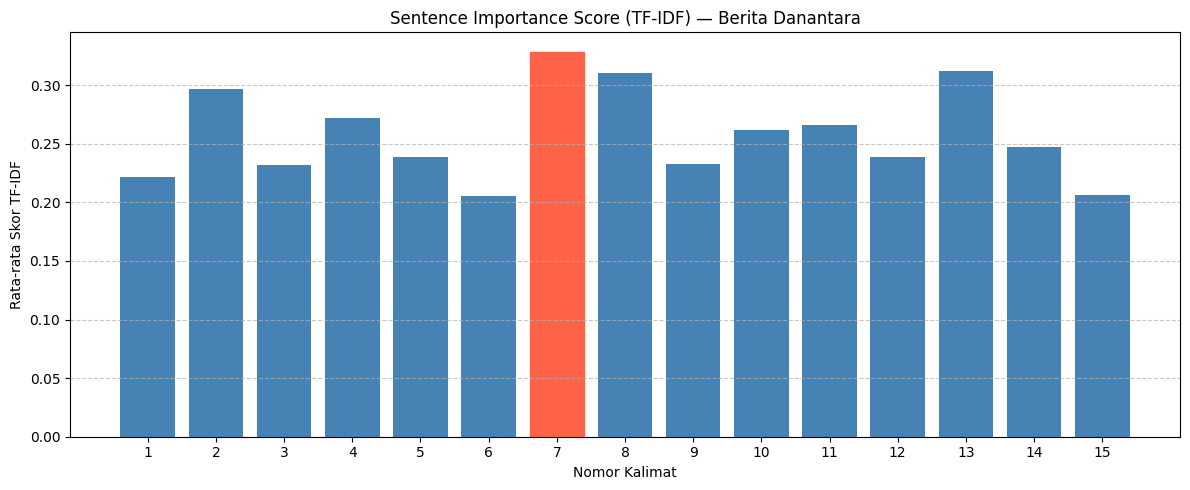


Penjelasan Histogram
Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan metode TF-IDF (Term Frequency–Inverse Document Frequency). Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat.

- Batang merah  → kalimat dengan skor tertinggi (paling informatif).
- Batang tinggi → kalimat mengandung kata spesifik & jarang muncul → kandidat kuat untuk ringkasan.
- Batang rendah → kalimat didominasi kata umum / informasi pendukung.


In [11]:
# VISUALISASI SENTENCE SCORE
plt.figure(figsize=(12, 5))
bars = plt.bar(range(1, len(sent_scores)+1), sent_scores, color='steelblue')

# Highlight bar tertinggi
max_idx = sent_scores.index(max(sent_scores))
bars[max_idx].set_color('tomato')

plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Sentence Importance Score (TF-IDF) — Berita Danantara")
plt.xticks(range(1, len(sent_scores)+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nPenjelasan Histogram")
print(
    "Setiap kalimat dalam berita dihitung tingkat kepentingannya menggunakan "
    "metode TF-IDF (Term Frequency\u2013Inverse Document Frequency). "
    "Nilai yang ditampilkan merupakan rata-rata skor TF-IDF tiap kalimat."
)
print(
    "\n- Batang merah  \u2192 kalimat dengan skor tertinggi (paling informatif)."
)
print(
    "- Batang tinggi \u2192 kalimat mengandung kata spesifik & jarang muncul \u2192 kandidat kuat untuk ringkasan."
)
print(
    "- Batang rendah \u2192 kalimat didominasi kata umum / informasi pendukung."
)

## 6. Define Threshold

In [12]:
# THRESHOLD = RATA-RATA SEMUA SENTENCE SCORES
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold")
print(f"Threshold (Rata-rata Sentence Score): {threshold:.6f}")
print(f"\nKalimat yang skornya >= {threshold:.4f} akan masuk ke ringkasan.")

Threshold
Threshold (Rata-rata Sentence Score): 0.258034

Kalimat yang skornya >= 0.2580 akan masuk ke ringkasan.


In [13]:
# CONTOH MANUAL: TF-IDF KATA 'investasi' PER KALIMAT

cleaned_lower = [s.lower() for s in sent_token]

def calculate_tf(term, document):
    words = word_tokenize(document)
    return words.count(term) / len(words) if words else 0

def calculate_idf(term, documents):
    doc_count = sum(1 for doc in documents if term in word_tokenize(doc))
    return math.log(len(documents) / doc_count) if doc_count > 0 else 0

term = "investasi"
idf_value = calculate_idf(term, cleaned_lower)
tfidf_per_sent = {}

for i, doc in enumerate(cleaned_lower):
    tf = calculate_tf(term, doc)
    tfidf_per_sent[f"Kalimat {i+1}"] = tf * idf_value

print(f"TF-IDF Manual untuk kata '{term}'")
for k, v in tfidf_per_sent.items():
    print(f"{k}: {v:.4f}")
print(f"\nIDF('{term}'): {idf_value:.4f}")

TF-IDF Manual untuk kata 'investasi'
Kalimat 1: 0.0762
Kalimat 2: 0.0000
Kalimat 3: 0.0263
Kalimat 4: 0.0448
Kalimat 5: 0.0000
Kalimat 6: 0.0000
Kalimat 7: 0.0000
Kalimat 8: 0.0000
Kalimat 9: 0.0231
Kalimat 10: 0.0346
Kalimat 11: 0.0000
Kalimat 12: 0.0331
Kalimat 13: 0.0000
Kalimat 14: 0.0544
Kalimat 15: 0.0000

IDF('investasi'): 0.7621


## 7. Generate Summary

In [14]:
# AMBIL KALIMAT DI ATAS THRESHOLD
final_summ = ""

print(f"Threshold: {threshold:.4f}")
print("\nKalimat yang Masuk Ringkasan")

for index, score in enumerate(sent_scores):
    if score >= threshold:
        final_summ += " " + sent_token[index]
        print(f"[{index+1}] (skor={score:.4f}) {sent_token[index]}")

print("\n" + "="*60)
print("HASIL RINGKASAN AKHIR")
print("="*60)
print(final_summ.strip())

Threshold: 0.2580

Kalimat yang Masuk Ringkasan
[2] (skor=0.2964) Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
[4] (skor=0.2722) Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
[7] (skor=0.3286) Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
[8] (skor=0.3101) Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
[10] (skor=0.2619) "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
[11] (skor=0.2656) Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
[13] (skor=0.3118) "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mi

## 8. Summarization Result

In [15]:
# TAMPILKAN RINGKASAN FINAL
print("RINGKASAN BERITA DANANTARA")
print(final_summ.strip())

RINGKASAN BERITA DANANTARA
Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.
